In [10]:
import pandas as pd

import numpy as np

import spacy

import re

import en_core_web_md

import string
from spacy.lang.en.stop_words import STOP_WORDS
from spacy.lang.en import English

import sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRFClassifier

In [11]:
nlp = en_core_web_md.load()

In [21]:
df = pd.read_csv('data.csv')

In [29]:
df.head()

,count,hate_speech_count,offensive_language_count,neither_count,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [42]:
df[df['class'] == 2]['tweet']

0        !!! RT @mayasolovely: As a woman you shouldn't...
40         " momma said no pussy cats inside my doghouse "
63       "@Addicted2Guys: -SimplyAddictedToGuys http://...
66       "@AllAboutManFeet: http://t.co/3gzUpfuMev" woo...
67       "@Allyhaaaaa: Lemmie eat a Oreo &amp; do these...
                               ...                        
24736    yaya ho.. cute avi tho RT @ViVaLa_Ari I had no...
24737    yea so about @N_tel 's new friend.. all my fri...
24767    you know what they say, the early bird gets th...
24779    you've gone and broke the wrong heart baby, an...
24782    ~~Ruffled | Ntac Eileen Dahlia - Beautiful col...
Name: tweet, Length: 4163, dtype: object

In [38]:
df['length'] = df['tweet'].apply(len) ##Feature engineering for length of tweet
df.length.describe()

count    24783.000000
mean        85.436065
std         41.548238
min          5.000000
25%         52.000000
50%         81.000000
75%        119.000000
max        754.000000
Name: length, dtype: float64

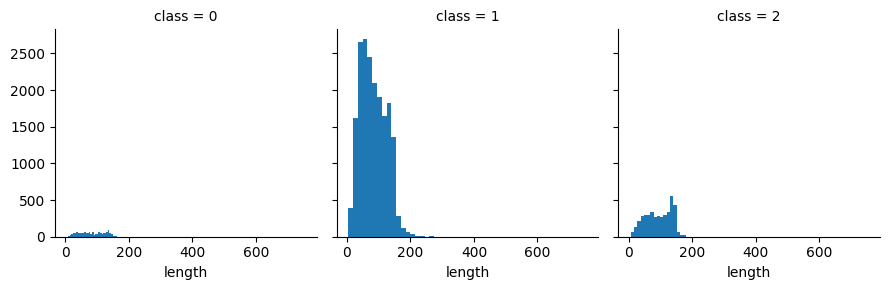

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
graph = sns.FacetGrid(data=df, col='class')
graph.map(plt.hist, 'length', bins=50)
